In [17]:
%%capture
%run "Fitting Pks Machinery.ipynb"

In [18]:
# Create a cosmology object with the same parameters as Flamingo
cosmo = ccl.Cosmology(h=0.681, Omega_b=0.0486, Omega_c=0.306-0.0486, n_s=0.967, sigma8=0.807)

Fit results: b1=8.599e-06, b2=1.377e-04, bs=-7.590e-06, bk2=2.619e-03, N=-3.466e-07, chi2/ndof=0.30
[ 8.59877522e-06  1.37728301e-04 -7.59027497e-06  2.61885702e-03
 -3.46598087e-07]


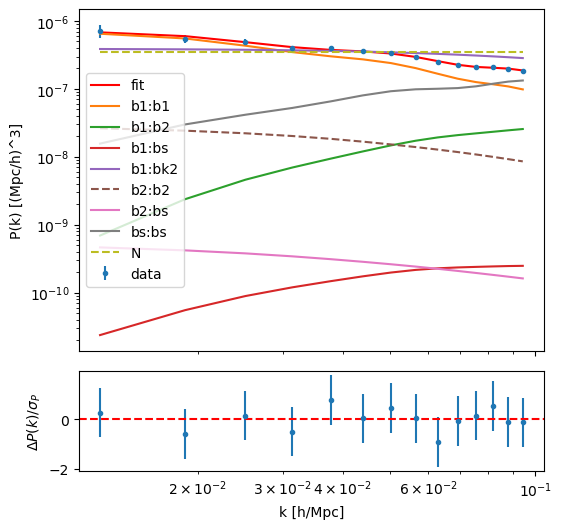

In [20]:
b_bf, b_cov = fit_pk(snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=0.1, kmin=0.01, plot = True, nl = True)[:2]

## Looking at change in coefficients w.r.t kmax

In [93]:
snpk = SnapPk('L1_m9', 67, kmax=10)

In [94]:
kmaxes = np.geomspace(0.1, 1, 40)

    
def coefficient_plotter(kmaxes, which = None):
    
    names = ['b1', 'b2', 'bs', 'bk2', 'N']
    
    if which is None:
        which = names
        
    for idx, name in enumerate(names):
        
        if name in which:
            parameters, errors = [], []
            parameters_nl, errors_nl = [], []
            
            for km in kmaxes:
                
                popt, pcov, _ = fit_pk(snpk.pks['matter_pressure'], snpk.epks['matter_pressure'], kmax=km, verbose=False, plot=False)
                popt_nl,  pcov_nl, _ = fit_pk(snpk.pks['pressure_pressure'], snpk.epks['pressure_pressure'], kmax=km, verbose=False, plot=False, nl = True)
                parameters.append(popt[idx])
                errors.append(np.sqrt(np.diag(pcov))[idx])
                parameters_nl.append(popt_nl[idx])
                errors_nl.append(np.sqrt(np.diag(pcov_nl))[idx])
                
            fig, ax = plt.subplots()
            ax.errorbar(kmaxes, parameters, yerr = errors, label = 'matter-pressure',
                        fmt='o-',        
                        capsize=3,     
                        capthick=1,     
                        elinewidth=1,   
                        markersize=4,
                       alpha = 0.7)
            ax.errorbar(kmaxes, parameters_nl, yerr = errors_nl, label = 'pressure-pressure',
                        fmt='o-',        
                        capsize=3,     
                        capthick=1,     
                        elinewidth=1,   
                        markersize=4,
                        alpha = 0.7)
            
            ax.set_xlabel(r'$k_{\max}$ [h/Mpc]')
            ax.set_ylabel('Bias value')
            ax.legend()
            ax.set_title(f'{name} against k');

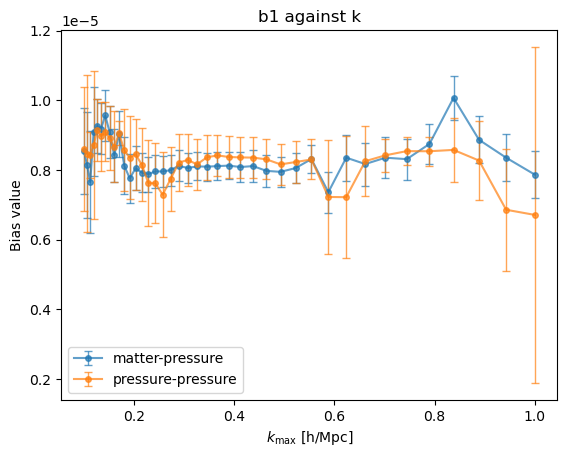

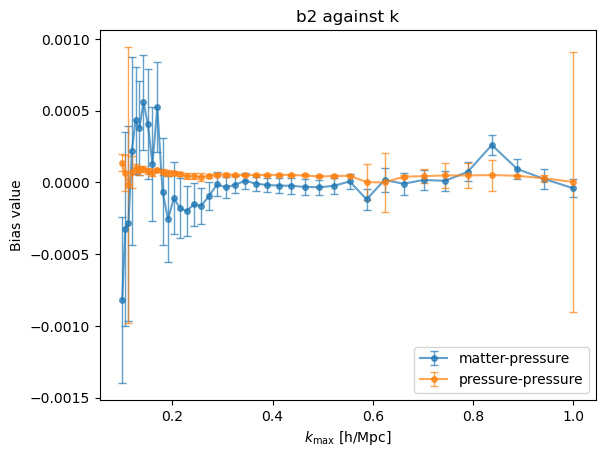

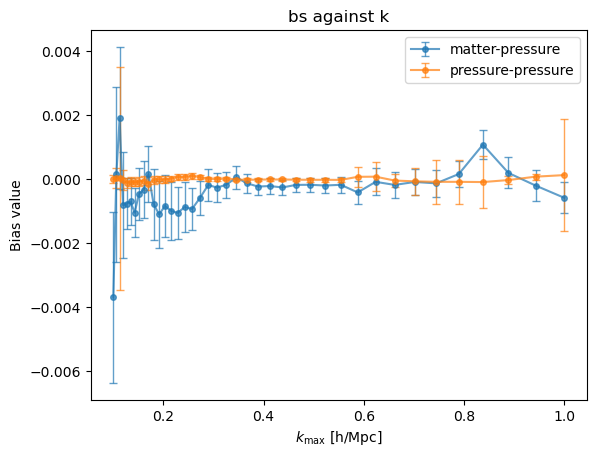

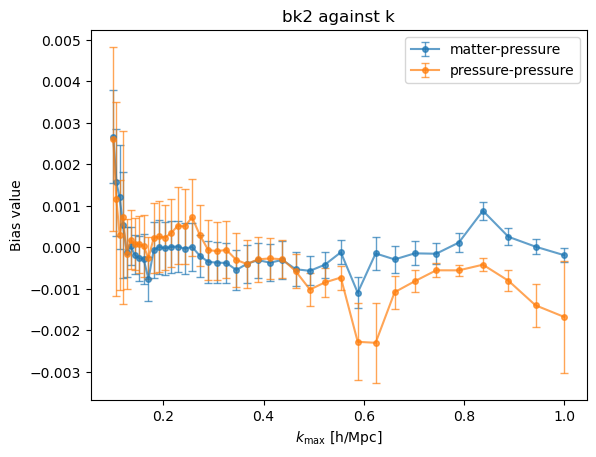

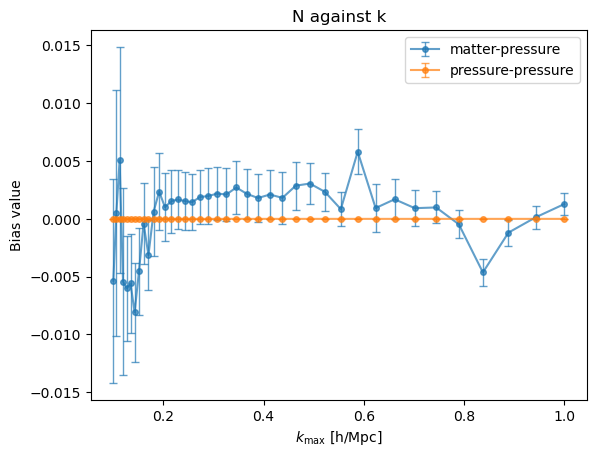

In [95]:
coefficient_plotter(kmaxes, which = None)

## Introducing Redshifts

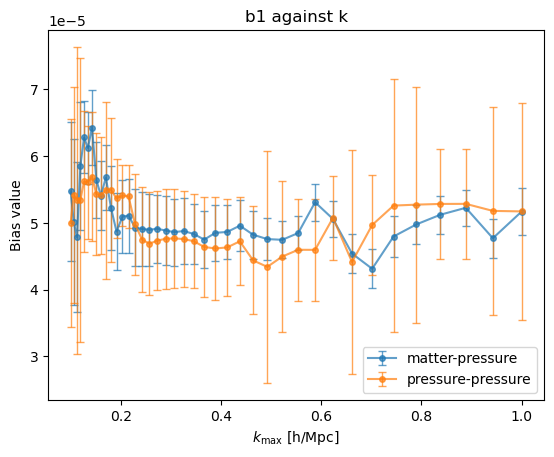

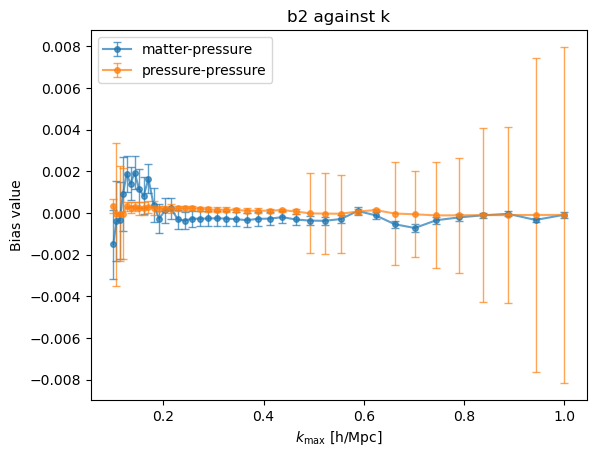

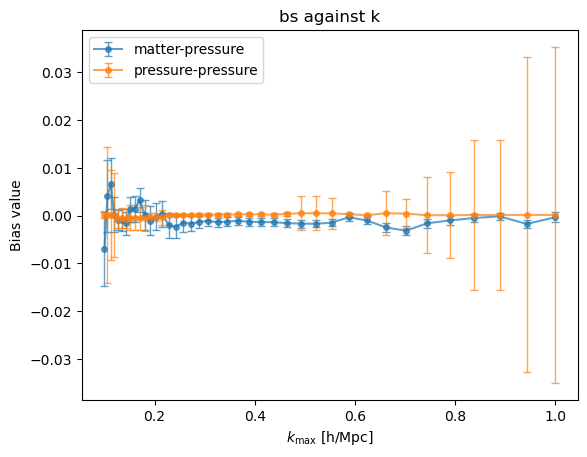

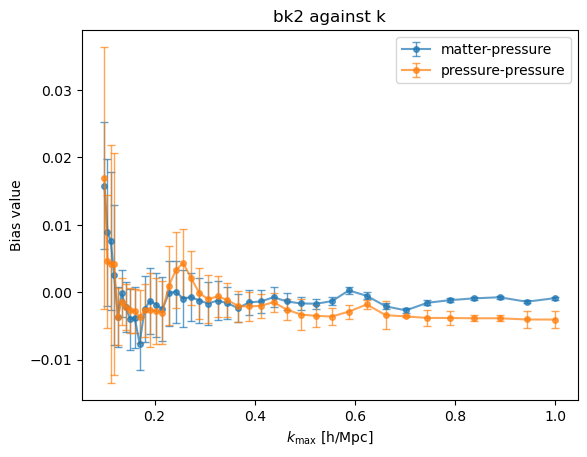

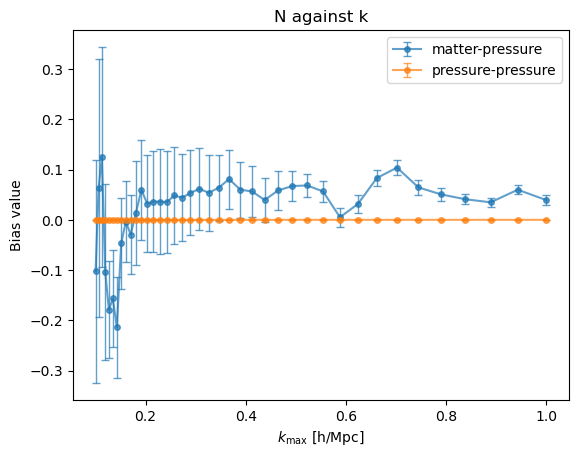

In [96]:
snpk = SnapPk('L1_m9', 100, kmax=10)
coefficient_plotter(kmaxes, which = None)

/tmp/ipykernel_2778/3266106401.py:36: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt((pk11*pk22+pk12**2)/nk)


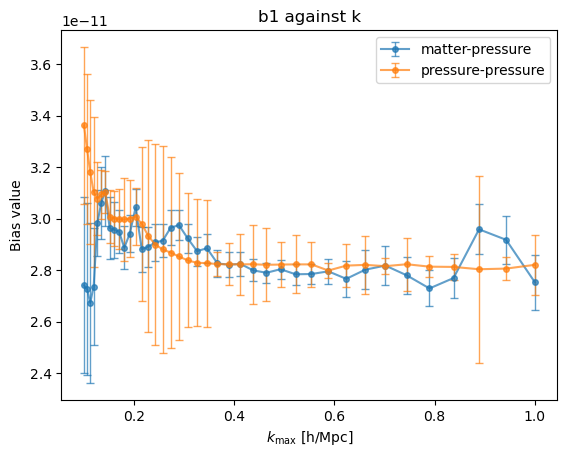

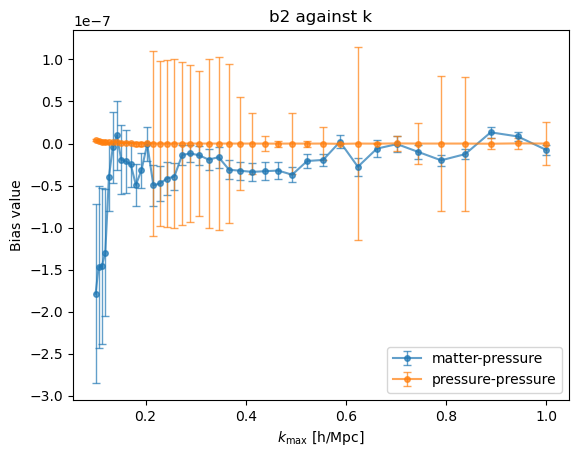

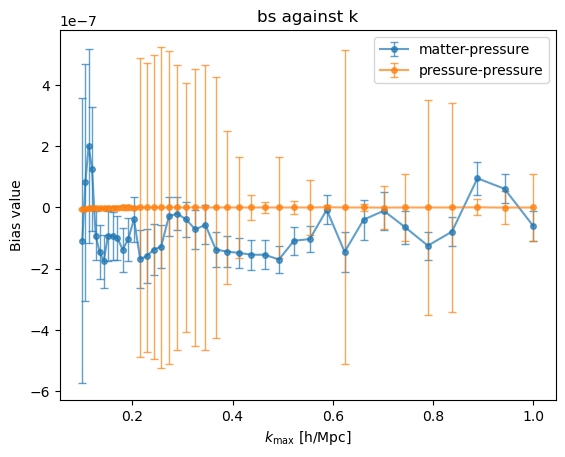

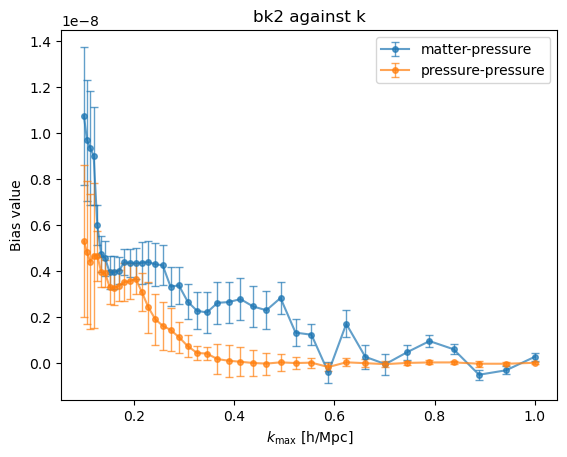

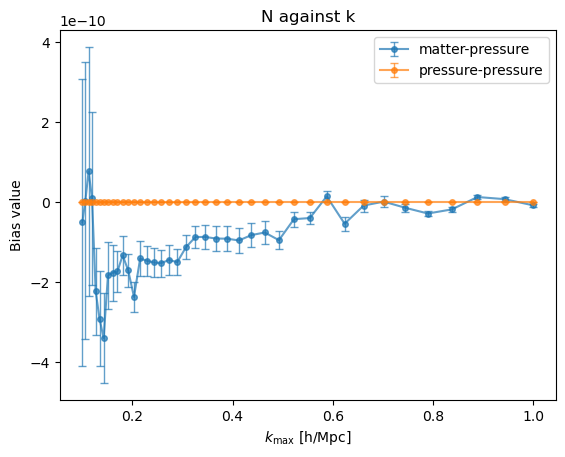

In [97]:
snpk = SnapPk('L1_m9', 0, kmax=10)
coefficient_plotter(kmaxes, which = None)